In [28]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from backend import load_data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier
from pypfopt import plotting
from pypfopt import EfficientFrontier, risk_models, expected_returns

In [29]:
prices, details = load_data("fund_prices.csv", "fund_detail.csv")

In [30]:
with open("frontend.json", "r", encoding="utf-8") as file:
    data = json.load(file)

risk_aversion = data.get("risk_aversion", 0)
print(risk_aversion)

prices_df, code_to_name = load_data('fund_prices.csv', 'fund_detail.csv')
fund_list = prices.columns
returns_df = prices_df.pct_change().dropna()

3.2333333333333334


In [7]:
mu = expected_returns.mean_historical_return(prices[fund_list])
S = risk_models.sample_cov(prices[fund_list])

In [ ]:

# Function to generate and plot everything with a given risk_aversion
def plot_efficient_frontier_with_optimal(mu, S, risk_aversion=1.5):
    plt.figure(figsize=(12, 8))
    
    # 1. Plot the efficient frontier without short selling
    ef_no_short = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    ax = plotting.plot_efficient_frontier(ef_no_short, show_assets=True,
                                      markerfacecolor='skyblue',
                                      label='Efficient Frontier (No Short)')
    
    # Get performance of max sharpe portfolio (for comparison)
    ef_no_short_sharpe = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    ef_no_short_sharpe.max_sharpe()
    ret_sharpe, vol_sharpe, _ = ef_no_short_sharpe.portfolio_performance()
    
    # Calculate optimal portfolio WITH NO SHORT for given risk_aversion
    ef_no_short_optimal = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    ef_no_short_optimal.add_constraint(lambda w: sum(w) == 1)
    weights_no_short = ef_no_short_optimal.max_quadratic_utility(risk_aversion=risk_aversion)
    returns_no_short, volatility_no_short, _ = ef_no_short_optimal.portfolio_performance()
    
    # 2. Plot the efficient frontier with short selling
    ef_short = EfficientFrontier(mu, S, weight_bounds=(-1, 1))
    # print(ef_short)
    ax = plotting.plot_efficient_frontier(ef_short, ax=ax, show_assets=False,
                                      markerfacecolor='red',
                                      label='Efficient Frontier (With Short)')
    
    # 3. Calculate optimal portfolio with short selling for given risk_aversion
    ef_optimal = EfficientFrontier(mu, S, weight_bounds=(-1, 1))
    ef_optimal.add_constraint(lambda w: sum(w) == 1)
    ef_optimal.add_constraint(lambda w: w >= -1)
    weights = ef_optimal.max_quadratic_utility(risk_aversion=risk_aversion)
    returns, volatility, _ = ef_optimal.portfolio_performance()
    
    # Mark the optimal points
    plt.scatter(volatility, returns, marker='*', s=200, color='green',
               label=f'Optimal Portfolio with Short (Risk Aversion={risk_aversion})')
    
    plt.scatter(volatility_no_short, returns_no_short, marker='*', s=200, color='blue',
               label=f'Optimal Portfolio No Short (Risk Aversion={risk_aversion})')
    
    # Mark the max sharpe point for reference
    plt.scatter(vol_sharpe, ret_sharpe, marker='o', s=150, color='purple',
               label='Max Sharpe (No Short)')
    
    # Chart formatting
    plt.title('Portfolio Efficient Frontier and Optimal Weights')
    plt.xlabel('Expected Risk (Standard Deviation)')
    plt.ylabel('Expected Return')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Output weight details
    print("Optimal Portfolio Weights:")
    # print(weights_df)
    print("\nPortfolio Performance:")
    print(f"Expected Annual Return: {returns:.4f}")
    print(f"Expected Annual Volatility: {volatility:.4f}")
    print(f"Sharpe Ratio: {returns/volatility:.4f}")
    
    return weights, returns, volatility

# Usage example
# Assuming you have mu and S ready:
# risk_aversion = 1.5  # Change this value to see different optimal portfolios
# weights, returns, volatility = plot_efficient_frontier_with_optimal(mu, S, risk_aversion)

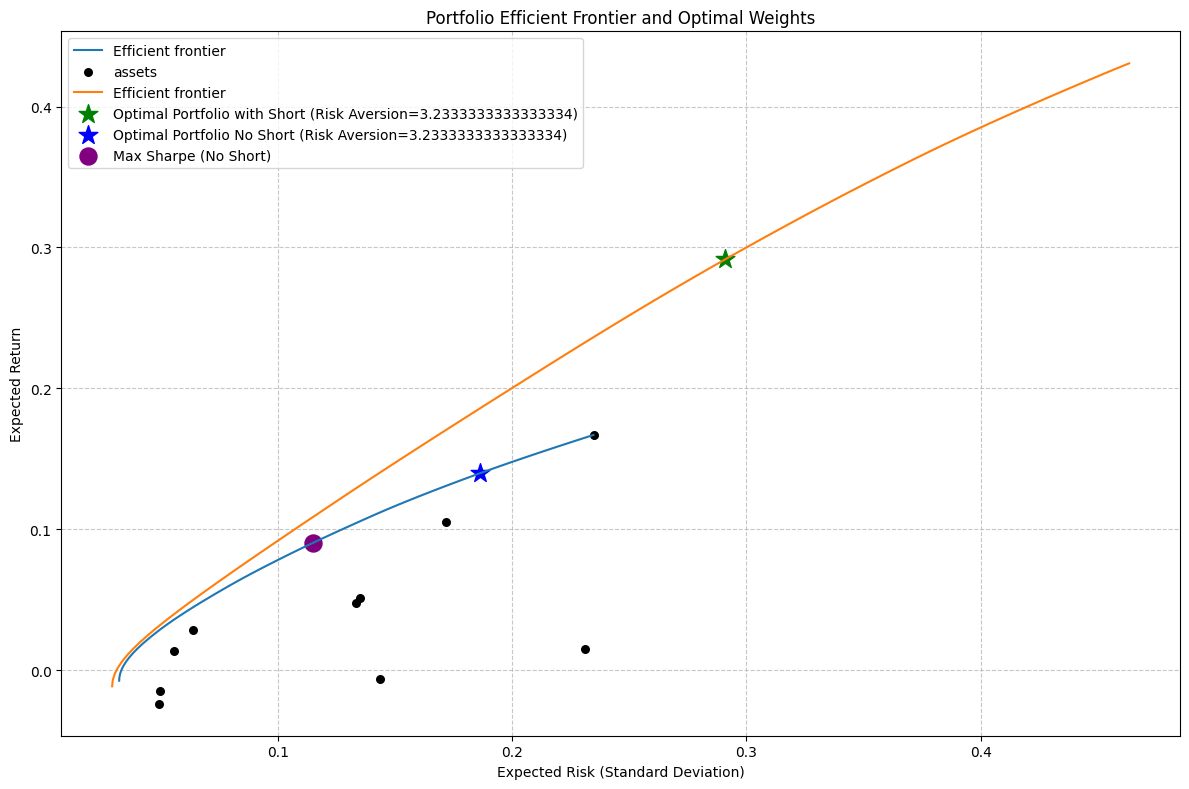

Optimal Portfolio Weights:

Portfolio Performance:
Expected Annual Return: 0.2916
Expected Annual Volatility: 0.2910
Sharpe Ratio: 1.0021


In [45]:
weights, returns, volatility = plot_efficient_frontier_with_optimal(mu, S, risk_aversion)

# JSON

In [56]:
def generate_efficient_frontier_data(prices, 
                                    risk_aversion, 
                                    returns_df=None, 
                                    code_to_name=None, 
                                    filename=r"backend.json"
):
    """
    生成有效前沿数据并以JSON格式返回，包括普通有效前沿和允许做空的有效前沿
    
    参数:
    - prices (pd.DataFrame): 价格数据
    - risk_aversion (float): 风险厌恶系数
    - returns_df (pd.DataFrame): 日收益率数据，用于确定资产代码
    - code_to_name (dict): 代码 -> 基金名称映射
    - filename (str): 输出文件路径
    
    返回:
    - JSON 字符串，包含有效前沿数据和最优投资组合数据
    """
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from pypfopt import EfficientFrontier, expected_returns, risk_models
    
    # 计算预期收益率和协方差矩阵
    mu = expected_returns.mean_historical_return(prices)
    S = risk_models.sample_cov(prices)
    
    # 从期望收益和协方差矩阵提取单个资产风险
    asset_returns = mu.values
    asset_risks = np.sqrt(np.diag(S.values))
    
    # 定义辅助函数，使用系统性方法生成有效前沿
    def compute_frontier(allow_short):
        weight_bounds = (-1, 1) if allow_short else (0, 1)
        
        # 生成一系列目标回报的最小风险投资组合
        # 让目标回报率范围更广，向右扩展以获取更多的有效前沿点
        target_min = np.min(asset_returns) - 0.05
        target_max = np.max(asset_returns) + 0.2  # 向右扩展更多
        target_returns = np.linspace(target_min, target_max, 100)  # 增加点数
        
        portfolio_risks = []
        valid_target_returns = []
        
        # 为每个目标回报率创建新的EfficientFrontier实例
        for target in target_returns:
            try:
                ef = EfficientFrontier(mu, S, weight_bounds=weight_bounds)
                if allow_short:
                    ef.add_constraint(lambda w: w >= -1)
                ef.add_constraint(lambda w: sum(w) == 1)
                
                # 设置目标回报率并最小化波动率
                ef.efficient_return(target_return=target)
                ret, vol, _ = ef.portfolio_performance()
                
                if not np.isnan(vol) and not np.isnan(ret):
                    portfolio_risks.append(vol)
                    valid_target_returns.append(ret)
            except Exception:
                continue
        
        # 添加最大夏普比率和最小波动率投资组合
        try:
            ef_max_sharpe = EfficientFrontier(mu, S, weight_bounds=weight_bounds)
            if allow_short:
                ef_max_sharpe.add_constraint(lambda w: w >= -1)
            ef_max_sharpe.add_constraint(lambda w: sum(w) == 1)
            ef_max_sharpe.max_sharpe()
            ret, vol, _ = ef_max_sharpe.portfolio_performance()
            portfolio_risks.append(vol)
            valid_target_returns.append(ret)
            
            ef_min_vol = EfficientFrontier(mu, S, weight_bounds=weight_bounds)
            if allow_short:
                ef_min_vol.add_constraint(lambda w: w >= -1)
            ef_min_vol.add_constraint(lambda w: sum(w) == 1)
            ef_min_vol.min_volatility()
            ret, vol, _ = ef_min_vol.portfolio_performance()
            portfolio_risks.append(vol)
            valid_target_returns.append(ret)
        except Exception as e:
            print(f"生成最优投资组合失败: {str(e)}")
        
        # 排序并格式化点
        if len(portfolio_risks) > 0:
            sorted_data = sorted(zip(portfolio_risks, valid_target_returns))
            sorted_risks = [x[0] for x in sorted_data]
            sorted_returns = [x[1] for x in sorted_data]
            
            return [{"risk": float(r), "return": float(ret)} 
                    for r, ret in zip(sorted_risks, sorted_returns)]
        else:
            # 最后的备用：至少返回几个单个资产的点
            return [{"risk": float(asset_risks[i]), "return": float(asset_returns[i])} 
                    for i in range(len(asset_returns))]
    
    # 生成两种有效前沿
    efficient_frontier_no_short = compute_frontier(allow_short=False)
    efficient_frontier_short = compute_frontier(allow_short=True)
    
    # 3. 计算不允许做空的最优投资组合 (根据风险厌恶系数)
    ef_no_short_optimal = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    ef_no_short_optimal.add_constraint(lambda w: sum(w) == 1)
    weights_no_short = ef_no_short_optimal.max_quadratic_utility(risk_aversion=risk_aversion)
    returns_no_short, volatility_no_short, _ = ef_no_short_optimal.portfolio_performance()
    
    # 4. 计算允许做空的最优投资组合 (根据风险厌恶系数)
    ef_optimal = EfficientFrontier(mu, S, weight_bounds=(-1, 1))
    ef_optimal.add_constraint(lambda w: sum(w) == 1)
    ef_optimal.add_constraint(lambda w: w >= -1)
    weights = ef_optimal.max_quadratic_utility(risk_aversion=risk_aversion)
    returns, volatility, _ = ef_optimal.portfolio_performance()
    
    # 5. 构建JSON数据结构
    if code_to_name is None:
        code_to_name = {}  # 如果没有提供映射，使用空字典
        
    # 使用价格DataFrame的列作为资产代码
    asset_codes = prices.columns
    
    chart_data = {
        "efficient_frontier_no_short": efficient_frontier_no_short,
        "efficient_frontier_short": efficient_frontier_short,
        "funds": [{"name": code_to_name.get(code, code), "risk": float(asset_risks[i]), "return": float(asset_returns[i])}
                 for i, code in enumerate(asset_codes)]
    }
    
    # 添加最优投资组合数据
    chart_data["optimal_portfolio"] = [
        {"name": "No Short", "risk": float(volatility_no_short), "return": float(returns_no_short)},
        {"name": "Short", "risk": float(volatility), "return": float(returns)}
    ]
    
    # 6. 保存JSON数据到文件
    with open(filename, "w") as f:
        json.dump(chart_data, f, indent=4)
    
    return json.dumps(chart_data, indent=4)

In [57]:
filename = os.path.join("./", "backend.json")
chart_json = generate_efficient_frontier_data(
    prices_df,
    risk_aversion,
    returns_df, 
    code_to_name)

with open(filename, 'w', encoding='utf-8') as f:
    f.write(chart_json)

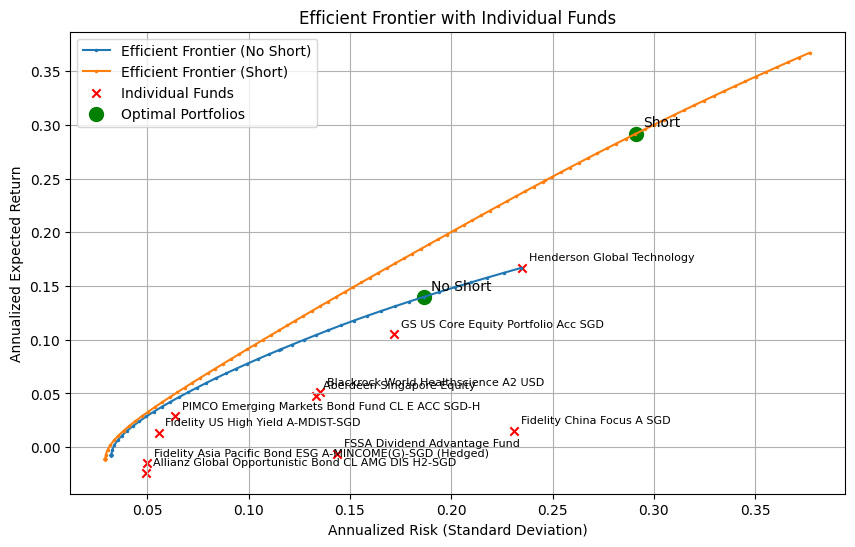

No short frontier points: 57
Short frontier points: 102
No short risks range: 0.03229818346270673 to 0.23422780399944979
No short returns range: -0.007416235170048756 to 0.1666822521299287
Short risks range: 0.029294365297723002 to 0.3769007604967908
Short returns range: -0.011394617514219175 to 0.3670441700321276


In [58]:

with open("backend.json", "r") as f:
    chart_data = json.load(f)

plt.figure(figsize=(10, 6))

# 绘制不允许空头的有效前沿
ef_no_short = chart_data["efficient_frontier_no_short"]
risks_no_short = [point["risk"] for point in ef_no_short]
returns_no_short = [point["return"] for point in ef_no_short]
plt.plot(risks_no_short, returns_no_short, marker='.', markersize=3, label='Efficient Frontier (No Short)')

# 绘制允许空头的有效前沿
ef_short = chart_data["efficient_frontier_short"]
risks_short = [point["risk"] for point in ef_short]
returns_short = [point["return"] for point in ef_short]
plt.plot(risks_short, returns_short, marker='.', markersize=3, label='Efficient Frontier (Short)')

# 绘制单个基金的散点图
funds = chart_data["funds"]
fund_risks = [fund["risk"] for fund in funds]
fund_returns = [fund["return"] for fund in funds]
fund_names = [fund["name"] for fund in funds]
plt.scatter(fund_risks, fund_returns, color='red', marker='x', label='Individual Funds')

# 标注基金名称
for i, name in enumerate(fund_names):
    plt.annotate(name, (fund_risks[i], fund_returns[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')

# 绘制最优投资组合点
optimal_portfolios = chart_data["optimal_portfolio"]
optimal_risks = [port["risk"] for port in optimal_portfolios]
optimal_returns = [port["return"] for port in optimal_portfolios]
optimal_names = [port["name"] for port in optimal_portfolios]
plt.scatter(optimal_risks, optimal_returns, color='green', marker='o', s=100, label='Optimal Portfolios')

# 标注最优投资组合
for i, name in enumerate(optimal_names):
    plt.annotate(name, (optimal_risks[i], optimal_returns[i]), fontsize=10, xytext=(5, 5), textcoords='offset points')

plt.xlabel('Annualized Risk (Standard Deviation)')
plt.ylabel('Annualized Expected Return')
plt.title('Efficient Frontier with Individual Funds')
plt.legend()
plt.grid(True)
plt.show()

print(f"No short frontier points: {len(risks_no_short)}")
print(f"Short frontier points: {len(risks_short)}")

# 检查数据范围
if risks_no_short:
    print(f"No short risks range: {min(risks_no_short)} to {max(risks_no_short)}")
    print(f"No short returns range: {min(returns_no_short)} to {max(returns_no_short)}")
if risks_short:
    print(f"Short risks range: {min(risks_short)} to {max(risks_short)}")
    print(f"Short returns range: {min(returns_short)} to {max(returns_short)}")
